In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importing libraries
import pandas as pd, numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Loading Dataset
url="https://raw.githubusercontent.com/nikitaguptasrivastava-cell/Information-Assurance/refs/heads/main/Credit_card_fraud_detection_dataset_csv.csv"
df_main=pd.read_csv(url)
df_main.head(20)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
1,T2,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
2,T3,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0
3,T4,2238,2733.84,Bill Payment,20.0,Mobile,San Francisco,2,68,1,Credit Card,0
4,T5,3433,4519.04,Bill Payment,13.0,Tablet,Boston,0,81,10,Credit Card,1
5,T6,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
6,T7,3904,821.79,ATM Withdrawal,7.0,Mobile,San Francisco,2,116,10,Credit Card,0
7,T8,3047,4413.05,Bank Transfer,21.0,Desktop,Boston,4,46,11,Credit Card,1
8,T9,1975,4972.42,Online Purchase,13.0,Tablet,Houston,1,93,14,Credit Card,0
9,T10,2528,2382.83,POS Payment,NaN,Unknown Device,New York,0,27,14,Credit Card,0


In [ ]:
# Loading excel file
url = "https://raw.githubusercontent.com/nikitaguptasrivastava-cell/Information-Assurance/main/locations_Count_Decimal.xlsx"
df_locations = pd.read_excel(url)
df_locations.head(10)

,Cities,Latitude,Longitude,Count
0,Boston,42.361145,-71.057083,63
1,Chicago,41.850030,-87.650050,81
2,Houston,29.763280,-95.358421,73
3,Los Angeles,34.052235,-118.243683,65
4,Miami,25.761681,-80.191788,71
5,New York,40.714270,-74.005970,59
6,San Francisco,37.773972,-122.431297,69
7,Seattle,47.606210,-122.332070,93


https://www.kaggle.com/datasets/ranjitmandal/fraud-detection-dataset-csv/data?select=Fraud+Detection+Dataset.csv

In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Exploratory Data Analysis")



            Exploratory Data Analysis             




In [ ]:
# Dimension of dataset
df_main.shape

(11646, 12)

In [ ]:
#
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11646 entries, 0 to 11645
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    11646 non-null  object 
 1   User_ID                           11646 non-null  int64  
 2   Transaction_Amount                11087 non-null  float64
 3   Transaction_Type                  11646 non-null  object 
 4   Time_of_Transaction               11014 non-null  float64
 5   Device_Used                       11082 non-null  object 
 6   Location                          11054 non-null  object 
 7   Previous_Fraudulent_Transactions  11646 non-null  int64  
 8   Account_Age                       11646 non-null  int64  
 9   Number_of_Transactions_Last_24H   11646 non-null  int64  
 10  Payment_Method                    11646 non-null  object 
 11  Fraudulent                        11646 non-null  int64  
dtypes: f

In [ ]:
df_main.describe() #obeserved that dataset has missing values

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,11646.000000,11087.000000,11014.000000,11646.000000,11646.000000,11646.000000,11646.000000
mean,3000.026704,3027.154358,11.497639,1.999485,60.156019,7.545767,0.049287
std,1151.171664,5217.557303,6.876962,1.417549,34.275107,4.024411,0.216477
min,1001.000000,5.470000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2000.000000,1269.365000,6.000000,1.000000,30.250000,4.000000,0.000000
50%,2992.000000,2518.500000,12.000000,2.000000,60.000000,8.000000,0.000000
75%,4005.000000,3798.020000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [ ]:
# checking the columns for null values
df_main.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,559
Transaction_Type,0
Time_of_Transaction,632
Device_Used,564
Location,592
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [ ]:
#finding the null percentages across columns
round(df_main.isnull().sum()/len(df_main.index),4)*100

,0
Transaction_ID,0.00
User_ID,0.00
Transaction_Amount,4.80
Transaction_Type,0.00
Time_of_Transaction,5.43
Device_Used,4.84
Location,5.08
Previous_Fraudulent_Transactions,0.00
Account_Age,0.00
Number_of_Transactions_Last_24H,0.00


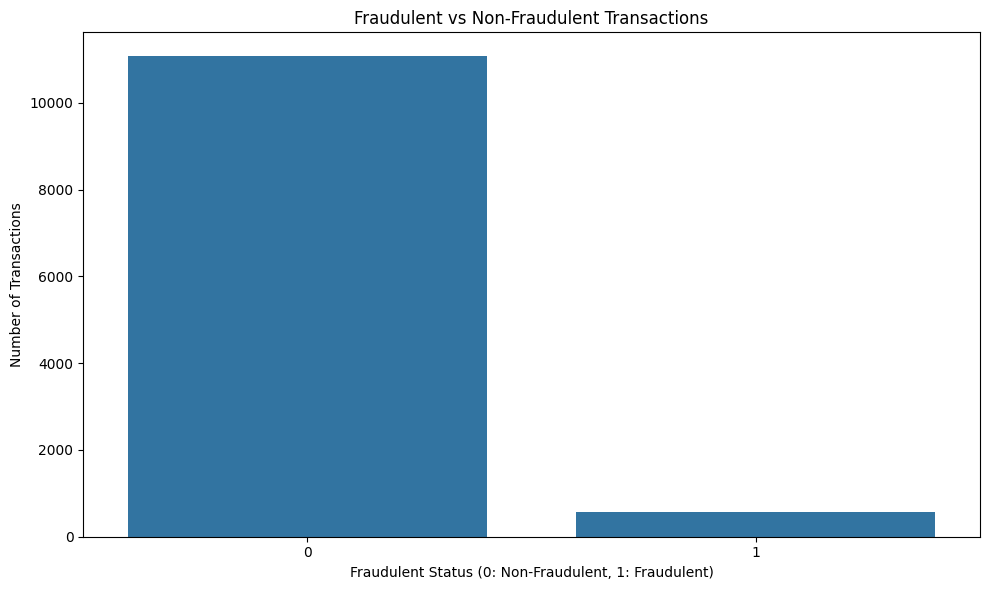

In [ ]:
# Combined bar graph showcasing fraudulent V/s non-Fraudulent classes
fig, axes = plt.subplots(figsize=(10, 6))
fraud_counts = df_main["Fraudulent"].value_counts().reset_index()
sns.barplot(x="Fraudulent", y="count", data=fraud_counts, ax=axes)
plt.title('Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Fraudulent Status (0: Non-Fraudulent, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

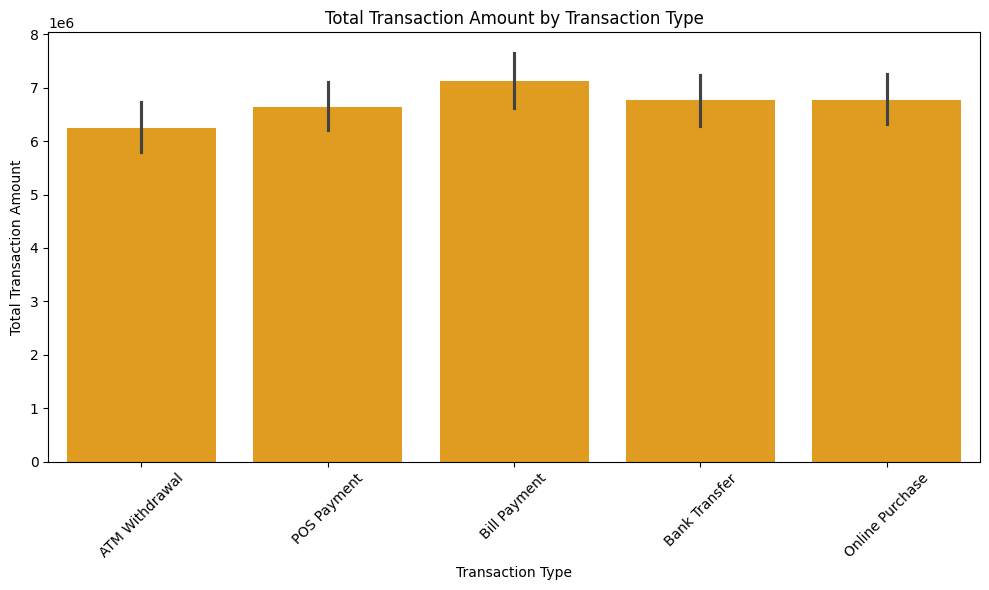

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Plotting average Transaction_Amount by Transaction_Type
plt.figure(figsize=(10, 6))
sns.barplot(x='Transaction_Type', y='Transaction_Amount', data=df_main, estimator=sum, color='Orange')
plt.title('Total Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

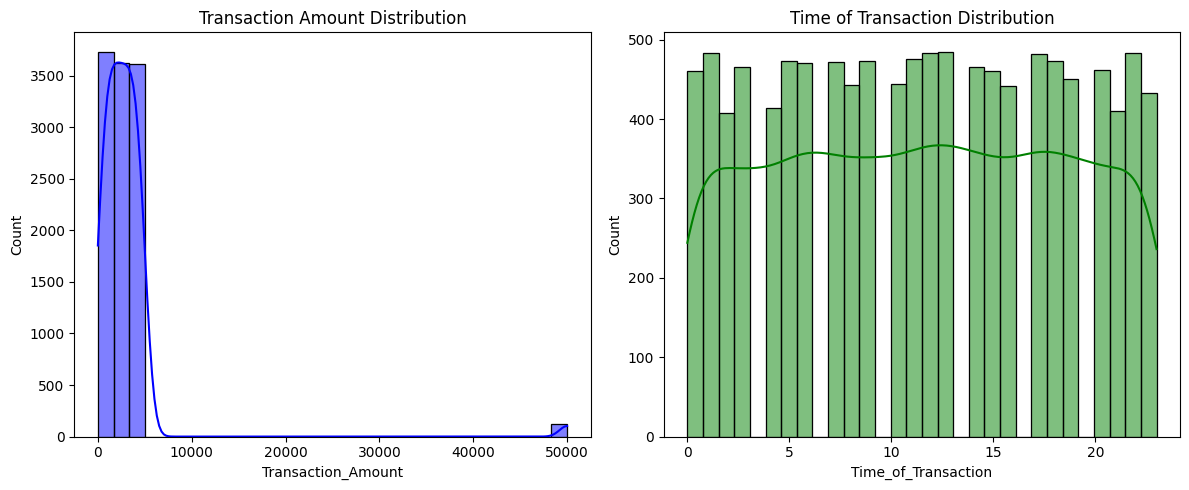

In [ ]:
# Visual check of distributions for numerical columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_main["Transaction_Amount"].dropna(), bins=30, kde=True, color="blue", ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].grid(False)
sns.histplot(df_main["Time_of_Transaction"].dropna(), bins=30, kde=True, color="green", ax=axes[1])
axes[1].set_title('Time of Transaction Distribution')
axes[1].grid(False)
plt.tight_layout()
plt.show()

In [ ]:
round(df_main["Device_Used"].value_counts(normalize=True),6)*100

,proportion
Device_Used,
Desktop,33.2341
Mobile,32.5032
Tablet,31.1857
Unknown Device,3.0771


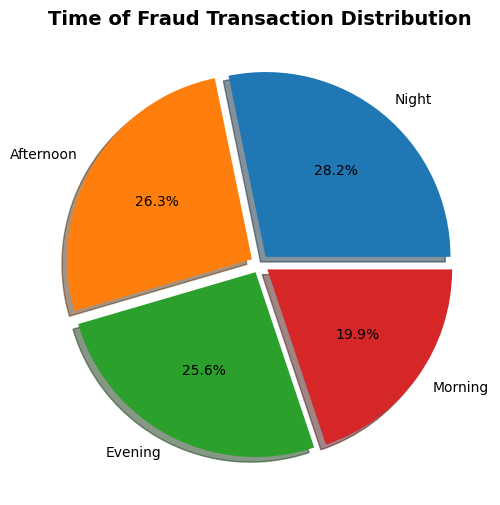

In [ ]:
#function for group hours
def time_period(hour):
  if hour in range(6,12):
    return "Morning"
  elif hour in range(12,18):
    return "Afternoon"
  elif hour in range(18,24):
    return "Evening"
  else:
    return "Night"

# Apply the function to create a new categorical column for time periods
df_main["Time_Period"] = df_main["Time_of_Transaction"].apply(time_period)
fraud_df = df_main[df_main["Fraudulent"] == 1]
counts = fraud_df["Time_Period"].value_counts()

# Create an explode tuple/list with the same length as the number of categories
# For example, to slightly explode all slices, create a list of 0.05 for each
explode_values = [0.05] * len(counts)

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', explode=explode_values,shadow=True)
plt.title('Time of Fraud Transaction Distribution', fontsize=14, fontweight="bold")
plt.show()

In [ ]:
import folium
from folium.plugins import HeatMap

#Center Map
map_center = [df_locations["Latitude"].mean(),df_locations["Longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=5)

In [ ]:
from textwrap import fill
heat_data = [[row['Latitude'], row['Longitude'],row["Count"]] for index, row in df_locations.iterrows()]

for index, row in df_locations.iterrows() : folium.CircleMarker(location=[row["Latitude"],row["Longitude"]], radius = 8, color = 'red', fill = True,
                                           fill_color = 'red', fill_opacity = 0.6, popup = f"{row["Cities"]} : {row["Count"]} frauds").add_to(m)

HeatMap(heat_data, radius = 25, max_zoom = 10).add_to(m)


m
m.save("map.html")

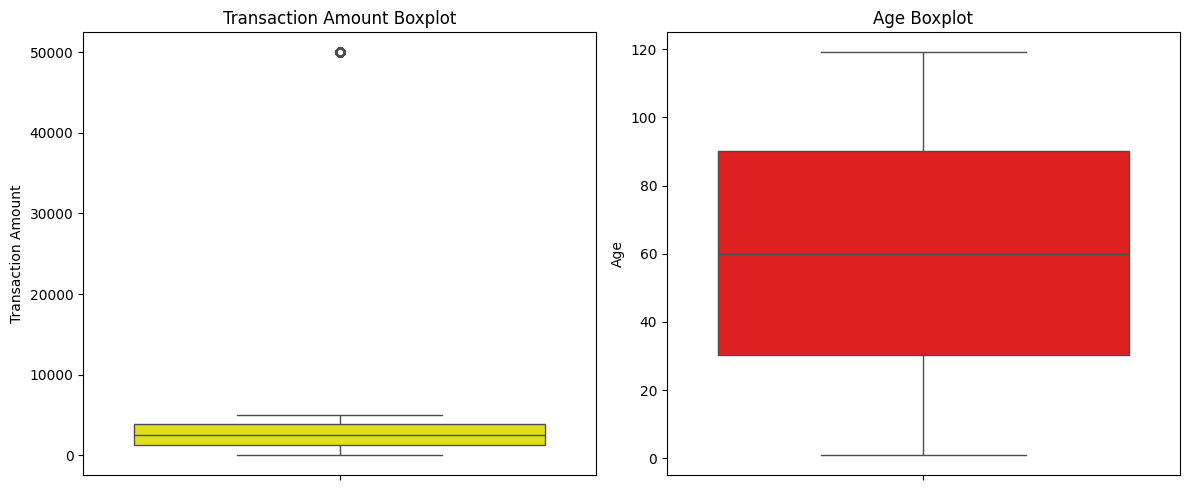

In [ ]:
# Combined boxplots for key numerical columns (in subplots) and outlier reporting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_main["Transaction_Amount"], ax=axes[0], color="yellow")
axes[0].set_title('Transaction Amount Boxplot')
axes[0].set_ylabel("Transaction Amount")
axes[0].grid(False)
sns.boxplot(y=df_main["Account_Age"], ax=axes[1], color="red")
axes[1].set_title('Age Boxplot')
axes[1].set_ylabel('Age')
axes[1].grid(False)
plt.tight_layout()
plt.show()

In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Data Cleaning")



                  Data Cleaning                   




In [ ]:
round(df_main["Location"].value_counts(normalize=True),6)*100


,proportion
Location,
Seattle,12.9546
Chicago,12.8641
Boston,12.5023
San Francisco,12.4932
Miami,12.3847
New York,12.3575
Houston,12.2399
Los Angeles,12.2037


In [ ]:
# Imputing the missing data in the 'City' column with 'Seattle'as it has the highest proportion
df_main["Location"]=df_main["Location"].replace(np.nan,'Seattle')

In [ ]:
# Finding the null percentages across columns
round(df_main.isnull().sum()/len(df_main.index),4)*100

,0
Transaction_ID,0.00
User_ID,0.00
Transaction_Amount,4.80
Transaction_Type,0.00
Time_of_Transaction,5.43
Device_Used,4.84
Location,0.00
Previous_Fraudulent_Transactions,0.00
Account_Age,0.00
Number_of_Transactions_Last_24H,0.00


In [ ]:
# Impute based on skewness
numerical_columns = ["Transaction_Amount", "Time_of_Transaction"]
for col1 in numerical_columns:
    skewness = df_main[col1].skew()
    print(f"{col1} skewness: {skewness:.2f}")
    if abs(skewness) > 0.5:
        impute_value = df_main[col1].median()
        method = 'median'
    else:
        impute_value = df_main[col1].mean()
        method = 'mean'
    missing_count = df_main[col1].isnull().sum()
    df_main[col1] = df_main[col1].fillna(impute_value)
    print(f"{col1}: Filled {missing_count} missing values with {method} ({impute_value:.2f})")

Transaction_Amount skewness: 8.20
Transaction_Amount: Filled 559 missing values with median (2518.50)
Time_of_Transaction skewness: -0.01
Time_of_Transaction: Filled 632 missing values with mean (11.50)


In [ ]:
round(df_main.isnull().sum()/len(df_main.index),4)*100

,0
Transaction_ID,0.00
User_ID,0.00
Transaction_Amount,0.00
Transaction_Type,0.00
Time_of_Transaction,0.00
Device_Used,4.84
Location,0.00
Previous_Fraudulent_Transactions,0.00
Account_Age,0.00
Number_of_Transactions_Last_24H,0.00


In [ ]:
# Handle categorical missing values for categorical columns
# Replacing Unknown and Unknown Device with Desktop
categorical_columns = ["Device_Used"]
for col in categorical_columns:
    missing_count = df_main[col].isnull().sum()
    df_main[col] = df_main[col].fillna('Desktop')
    print(f"{col}: Filled {missing_count} missing values with 'Desktop'")
df_main[categorical_columns] = df_main[categorical_columns].replace(['Unknown' , 'Unknown Device'], 'Desktop')
original_df=df_main.copy()

Device_Used: Filled 564 missing values with 'Desktop'


In [ ]:
df_main.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Time_of_Transaction,0
Device_Used,0
Location,0
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [ ]:
df_main.head(20)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Time_Period
0,T1,4507,1554.58,ATM Withdrawal,13.000000,Mobile,New York,4,79,3,Credit Card,0,Afternoon
1,T2,2130,1490.50,POS Payment,19.000000,Mobile,San Francisco,2,57,7,Credit Card,0,Evening
2,T3,2095,2372.04,ATM Withdrawal,15.000000,Desktop,Boston,3,96,14,Credit Card,0,Afternoon
3,T4,2238,2733.84,Bill Payment,20.000000,Mobile,San Francisco,2,68,1,Credit Card,0,Evening
4,T5,3433,4519.04,Bill Payment,13.000000,Tablet,Boston,0,81,10,Credit Card,1,Afternoon
5,T6,3324,428.39,POS Payment,20.000000,Desktop,New York,0,85,10,Credit Card,0,Evening
6,T7,3904,821.79,ATM Withdrawal,7.000000,Mobile,San Francisco,2,116,10,Credit Card,0,Morning
7,T8,3047,4413.05,Bank Transfer,21.000000,Desktop,Boston,4,46,11,Credit Card,1,Evening
8,T9,1975,4972.42,Online Purchase,13.000000,Tablet,Houston,1,93,14,Credit Card,0,Afternoon
9,T10,2528,2382.83,POS Payment,11.497639,Desktop,New York,0,27,14,Credit Card,0,Night


In [ ]:
df_main = df_main[df_main["Transaction_Amount"] < 49997]

In [ ]:
#checking for Duplicates
df_main[df_main.duplicated()]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Time_Period


In [ ]:
df_main.shape

(11521, 13)

In [ ]:
#Clean Original Dataset
df_main.head(20)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Time_Period
0,T1,4507,1554.58,ATM Withdrawal,13.000000,Mobile,New York,4,79,3,Credit Card,0,Afternoon
1,T2,2130,1490.50,POS Payment,19.000000,Mobile,San Francisco,2,57,7,Credit Card,0,Evening
2,T3,2095,2372.04,ATM Withdrawal,15.000000,Desktop,Boston,3,96,14,Credit Card,0,Afternoon
3,T4,2238,2733.84,Bill Payment,20.000000,Mobile,San Francisco,2,68,1,Credit Card,0,Evening
4,T5,3433,4519.04,Bill Payment,13.000000,Tablet,Boston,0,81,10,Credit Card,1,Afternoon
5,T6,3324,428.39,POS Payment,20.000000,Desktop,New York,0,85,10,Credit Card,0,Evening
6,T7,3904,821.79,ATM Withdrawal,7.000000,Mobile,San Francisco,2,116,10,Credit Card,0,Morning
7,T8,3047,4413.05,Bank Transfer,21.000000,Desktop,Boston,4,46,11,Credit Card,1,Evening
8,T9,1975,4972.42,Online Purchase,13.000000,Tablet,Houston,1,93,14,Credit Card,0,Afternoon
9,T10,2528,2382.83,POS Payment,11.497639,Desktop,New York,0,27,14,Credit Card,0,Night


In [ ]:
# Remove rows where 'Transaction_Amount' is 50000
initial_rows = df_main.shape[0]
df_main = df_main[df_main['Transaction_Amount'] != 50000]
removed_rows = initial_rows - df_main.shape[0]

print(f"Number of rows removed where Transaction_Amount was 50000: {removed_rows}")
print(f"New DataFrame shape after removing specific transaction amount: {df_main.shape}")

Number of rows removed where Transaction_Amount was 50000: 0
New DataFrame shape after removing specific transaction amount: (11521, 13)


In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Data PreProcessing")



                Data PreProcessing                




In [ ]:
#Developing synthetic dataset
#Finding fraudscore
#Normalizing dataset
#Normalizing the columns by creating a normalize function
def normalize(columns):
  return (columns - columns.min()) / (columns.max() - columns.min())

df_main["Normalized_Amt"] = normalize(df_main["Transaction_Amount"])

df_main["Normalized_History"] = normalize(df_main["Previous_Fraudulent_Transactions"])

df_main["Normalized_Frequency"] = normalize(df_main["Number_of_Transactions_Last_24H"])

df_main["Normalized_Time"] = normalize(df_main["Time_of_Transaction"])

df_main["Nomalized_Age"] = normalize(df_main["Account_Age"])

#Assign risk weights to
#using the probability of occurence and for example fraud_rate/max_fraud_rate from original dataset so risk score varies between 0 to 1,calculated the transaction type risk
Transaction_Type_Risk = {
    "Bill Payment":0.95,
    "ATM Withdrawal":1,
    "POS Payment":0.97,
    "Bank Transfer":0.99,
    "Online Purchase":0.99
}
df_main["Normalized_Transaction_Type"] = df_main["Transaction_Type"].map(Transaction_Type_Risk)
device_risk = {
    "Mobile":0.88,
    "Desktop":1,
    "Tablet":0.77
}
df_main["Normalized_Device"]= df_main["Device_Used"].map(device_risk)

Location_risk = {
    "Boston":0.68,
    "Seattle":1,
    "Chicago":0.87,
    "Houston":0.78,
    "New York":0.63,
    "Los Angeles":0.69,
    "Miami":0.76,
    "San Francisco":0.74
}

df_main["Normalized_Location"]= df_main["Location"].map(Location_risk)
df_main_normalized=df_main.copy()
df_main.head(20)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,...,Fraudulent,Time_Period,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
0,T1,4507,1554.58,ATM Withdrawal,13.000000,Mobile,New York,4,79,3,...,0,Afternoon,0.310233,1.00,0.153846,0.565217,0.661017,1.00,0.88,0.63
1,T2,2130,1490.50,POS Payment,19.000000,Mobile,San Francisco,2,57,7,...,0,Evening,0.297400,0.50,0.461538,0.826087,0.474576,0.97,0.88,0.74
2,T3,2095,2372.04,ATM Withdrawal,15.000000,Desktop,Boston,3,96,14,...,0,Afternoon,0.473941,0.75,1.000000,0.652174,0.805085,1.00,1.00,0.68
3,T4,2238,2733.84,Bill Payment,20.000000,Mobile,San Francisco,2,68,1,...,0,Evening,0.546397,0.50,0.000000,0.869565,0.567797,0.95,0.88,0.74
4,T5,3433,4519.04,Bill Payment,13.000000,Tablet,Boston,0,81,10,...,1,Afternoon,0.903911,0.00,0.692308,0.565217,0.677966,0.95,0.77,0.68
5,T6,3324,428.39,POS Payment,20.000000,Desktop,New York,0,85,10,...,0,Evening,0.084696,0.00,0.692308,0.869565,0.711864,0.97,1.00,0.63
6,T7,3904,821.79,ATM Withdrawal,7.000000,Mobile,San Francisco,2,116,10,...,0,Morning,0.163480,0.50,0.692308,0.304348,0.974576,1.00,0.88,0.74
7,T8,3047,4413.05,Bank Transfer,21.000000,Desktop,Boston,4,46,11,...,1,Evening,0.882685,1.00,0.769231,0.913043,0.381356,0.99,1.00,0.68
8,T9,1975,4972.42,Online Purchase,13.000000,Tablet,Houston,1,93,14,...,0,Afternoon,0.994707,0.25,1.000000,0.565217,0.779661,0.99,0.77,0.78
9,T10,2528,2382.83,POS Payment,11.497639,Desktop,New York,0,27,14,...,0,Night,0.476102,0.00,1.000000,0.499897,0.220339,0.97,1.00,0.63


In [ ]:
#df_main=df_main.drop(columns=['Transaction_ID','User_ID','Transaction_Amount','Transaction_Type','Time_of_Transaction','Device_Used','Location','Previous_Fraudulent_Transactions',
   #                 'Account_Age','Number_of_Transactions_Last_24H','Payment_Method'])
df_main_normalized=df_main_normalized.drop(columns=['Transaction_ID','Transaction_Amount','Transaction_Type','Time_of_Transaction','Device_Used','Location','Previous_Fraudulent_Transactions',
                    'Account_Age','Number_of_Transactions_Last_24H','Payment_Method','Time_Period'])

In [ ]:
df_main_normalized.head(20)

,User_ID,Fraudulent,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
0,4507,0,0.310233,1.00,0.153846,0.565217,0.661017,1.00,0.88,0.63
1,2130,0,0.297400,0.50,0.461538,0.826087,0.474576,0.97,0.88,0.74
2,2095,0,0.473941,0.75,1.000000,0.652174,0.805085,1.00,1.00,0.68
3,2238,0,0.546397,0.50,0.000000,0.869565,0.567797,0.95,0.88,0.74
4,3433,1,0.903911,0.00,0.692308,0.565217,0.677966,0.95,0.77,0.68
5,3324,0,0.084696,0.00,0.692308,0.869565,0.711864,0.97,1.00,0.63
6,3904,0,0.163480,0.50,0.692308,0.304348,0.974576,1.00,0.88,0.74
7,3047,1,0.882685,1.00,0.769231,0.913043,0.381356,0.99,1.00,0.68
8,1975,0,0.994707,0.25,1.000000,0.565217,0.779661,0.99,0.77,0.78
9,2528,0,0.476102,0.00,1.000000,0.499897,0.220339,0.97,1.00,0.63


In [ ]:
df_main_normalized.describe()

,User_ID,Fraudulent,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
count,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000
mean,3000.903394,0.048867,0.498136,0.499631,0.503262,0.500038,0.501292,0.979954,0.894584,0.782230
std,1150.787375,0.215600,0.282162,0.354098,0.309491,0.290773,0.290271,0.017843,0.095146,0.120007
min,1001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.950000,0.770000,0.630000
25%,2001.000000,0.000000,0.262447,0.250000,0.230769,0.260870,0.254237,0.970000,0.770000,0.690000
50%,2992.000000,0.000000,0.503272,0.500000,0.538462,0.499897,0.500000,0.990000,0.880000,0.760000
75%,4005.000000,0.000000,0.738029,0.750000,0.769231,0.739130,0.754237,0.990000,1.000000,0.870000
max,4999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


==================================================
Weights
==================================================

In [ ]:
df_new = pd.DataFrame(index=range(8))
print(df_new)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7]


In [ ]:
df_weights = pd.DataFrame(index=[0])
df_weights['const'] = 0
df_weights['Normalized_Amt'] = 0.28
df_weights['Normalized_History'] = 0.22
df_weights['Normalized_Frequency'] = 0.18
df_weights['Normalized_Time'] = 0.12
df_weights['Nomalized_Age'] = 0.08
df_weights['Normalized_Transaction_Type'] = 0.06
df_weights['Normalized_Device'] = 0.04
df_weights['Normalized_Location'] = 0.02

In [ ]:
print(df_weights['Normalized_Amt'].iloc[0]*df_main_normalized['Normalized_Amt'])

0        0.086865
1        0.083272
2        0.132704
3        0.152991
4        0.253095
           ...   
11641    0.045657
11642    0.237021
11643    0.106741
11644    0.162200
11645    0.123305
Name: Normalized_Amt, Length: 11521, dtype: float64


In [ ]:
df_weights['Normalized_History'].iloc[0]*df_main_normalized['Normalized_History']

,Normalized_History
0,0.220
1,0.110
2,0.165
3,0.110
4,0.000
...,...
11641,0.000
11642,0.055
11643,0.220
11644,0.110


In [ ]:
df_main_normalized.describe()

,User_ID,Fraudulent,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
count,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000,11521.000000
mean,3000.903394,0.048867,0.498136,0.499631,0.503262,0.500038,0.501292,0.979954,0.894584,0.782230
std,1150.787375,0.215600,0.282162,0.354098,0.309491,0.290773,0.290271,0.017843,0.095146,0.120007
min,1001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.950000,0.770000,0.630000
25%,2001.000000,0.000000,0.262447,0.250000,0.230769,0.260870,0.254237,0.970000,0.770000,0.690000
50%,2992.000000,0.000000,0.503272,0.500000,0.538462,0.499897,0.500000,0.990000,0.880000,0.760000
75%,4005.000000,0.000000,0.738029,0.750000,0.769231,0.739130,0.754237,0.990000,1.000000,0.870000
max,4999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#Calculating fraud score
df_main_normalized["Fraud_Score"] = (df_weights['const'].iloc[0]+
                                    df_weights['Normalized_Amt'].iloc[0]*df_main_normalized['Normalized_Amt'] +
                                    df_weights['Normalized_History'].iloc[0]*df_main_normalized['Normalized_History'] +
                                    df_weights['Normalized_Frequency'].iloc[0]*df_main_normalized['Normalized_Frequency'] +
                                    df_weights['Normalized_Time'].iloc[0]*df_main_normalized['Normalized_Time'] +
                                    df_weights['Nomalized_Age'].iloc[0]*df_main_normalized['Nomalized_Age'] +
                                    df_weights['Normalized_Transaction_Type'].iloc[0]*df_main_normalized['Normalized_Transaction_Type'] +
                                    df_weights['Normalized_Device'].iloc[0]*df_main_normalized['Normalized_Device'] +
                                    df_weights['Normalized_Location'].iloc[0]*df_main_normalized['Normalized_Location'])

In [ ]:
df_risk_amount_average = (df_weights['Normalized_Amt'].iloc[0]*df_main_normalized['Normalized_Amt']).mean()
print("Amount:",df_risk_amount_average)
df_risk_history_average = (df_weights['Normalized_History'].iloc[0]*df_main_normalized['Normalized_History']).mean()
print("Hsitory:",df_risk_history_average)
df_risk_frequency_average = (df_weights['Normalized_Frequency'].iloc[0]*df_main_normalized['Normalized_Frequency']).mean()
print("Frequency:",df_risk_frequency_average)
df_risk_time_average = (df_weights['Normalized_Time'].iloc[0]*df_main_normalized['Normalized_Time']).mean()
print("Time:",df_risk_time_average)
df_risk_age_average = (df_weights['Nomalized_Age'].iloc[0]*df_main_normalized['Nomalized_Age']).mean()
print("Age:",df_risk_age_average)
df_risk_type_average = (df_weights['Normalized_Transaction_Type'].iloc[0]*df_main_normalized['Normalized_Transaction_Type']).mean()
print("Type:",df_risk_type_average)
df_risk_device_average = (df_weights['Normalized_Device'].iloc[0]*df_main_normalized['Normalized_Device']).mean()
print("Device: ", df_risk_device_average)
df_risk_location_average = (df_weights['Normalized_Location'].iloc[0]*df_main_normalized['Normalized_Location']).mean()
print("Location: ",df_risk_location_average)
print("25% range" , 0.25*((0.139478201992489+0.01564459682319243)/2))
print("90% range" , 0.90*((0.139478201992489+0.01564459682319243)/2))


Amount: 0.139478201992489
Hsitory: 0.10991884385036021
Frequency: 0.09058708846053692
Time: 0.06000453866598968
Age: 0.04010339262569898
Type: 0.058797239822932036
Device:  0.03578335213957122
Location:  0.01564459682319243
25% range 0.01939034985196018
90% range 0.06980525946705665


In [ ]:
df_fraud_min=min(df_main_normalized["Fraud_Score"])
df_fraud_max=max(df_main_normalized["Fraud_Score"])
print("Minimum fraud score" ,df_fraud_min)
print("Maximum fraud score", df_fraud_max)


Minimum fraud score 0.15788451642856496
Maximum fraud score 0.9642403210868138


In [ ]:
percentile_25 = df_main_normalized["Fraud_Score"].quantile(0.25)
percentile_90 = df_main_normalized["Fraud_Score"].quantile(0.90)
print("25% Percentile" , percentile_25)
print("90% Percentile" , percentile_90)


25% Percentile 0.4583634699099047
90% Percentile 0.7236778697007877


In [ ]:
df_main_normalized["Fraudulent"]=pd.cut(df_main_normalized["Fraud_Score"],bins=[df_fraud_min,percentile_25,percentile_90,df_fraud_max],labels=[0,1,2], include_lowest=True)
print(df_main_normalized.head(20))
class_0_count = np.bincount(df_main_normalized["Fraudulent"])[0]
class_1_count = np.bincount(df_main_normalized["Fraudulent"])[1]
class_2_count = np.bincount(df_main_normalized["Fraudulent"])[2]
print(class_2_count)
print(class_1_count)
print(class_0_count)

    User_ID Fraudulent  Normalized_Amt  Normalized_History  \
0      4507          1        0.310233                1.00   
1      2130          1        0.297400                0.50   
2      2095          2        0.473941                0.75   
3      2238          1        0.546397                0.50   
4      3433          1        0.903911                0.00   
5      3324          0        0.084696                0.00   
6      3904          1        0.163480                0.50   
7      3047          2        0.882685                1.00   
8      1975          2        0.994707                0.25   
9      2528          1        0.476102                0.00   
10     4556          1        0.492578                0.50   
11     4890          1        0.535771                0.75   
12     3888          1        0.487255                0.25   
13     3824          0        0.156629                0.25   
14     1034          1        0.275893                0.75   
15     3

In [ ]:
df_main_normalized.head(20)

,User_ID,Fraudulent,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location,Fraud_Score
0,4507,1,0.310233,1.00,0.153846,0.565217,0.661017,1.00,0.88,0.63,0.563065
1,2130,1,0.297400,0.50,0.461538,0.826087,0.474576,0.97,0.88,0.74,0.521645
2,2095,2,0.473941,0.75,1.000000,0.652174,0.805085,1.00,1.00,0.68,0.733971
3,2238,1,0.546397,0.50,0.000000,0.869565,0.567797,0.95,0.88,0.74,0.519763
4,3433,1,0.903911,0.00,0.692308,0.565217,0.677966,0.95,0.77,0.68,0.601174
5,3324,0,0.084696,0.00,0.692308,0.869565,0.711864,0.97,1.00,0.63,0.420427
6,3904,1,0.163480,0.50,0.692308,0.304348,0.974576,1.00,0.88,0.74,0.504878
7,3047,2,0.882685,1.00,0.769231,0.913043,0.381356,0.99,1.00,0.68,0.858687
8,1975,2,0.994707,0.25,1.000000,0.565217,0.779661,0.99,0.77,0.78,0.749517
9,2528,1,0.476102,0.00,1.000000,0.499897,0.220339,0.97,1.00,0.63,0.501723


==================================================
Splitting the dataset
===========================

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df_main_normalized.drop(columns=['Fraudulent'],axis=1)
y_actual=df_main_normalized['Fraudulent']
print("Original Normalized Dataset wihtout Fruadulent column\n")
print(X[:20]
)
print(" Fruadulent column\n")
print(y_actual[:20]
)
#split the data
# First split: 80% for training, 20% for temp (test + validate)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_actual, train_size=0.8, random_state=42)

# Second split: 50% of temp for test (0.1 of original), 50% for validate (0.1 of original)
X_test, X_validate, y_test, y_validate = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

Original Normalized Dataset wihtout Fruadulent column

    User_ID  Normalized_Amt  Normalized_History  Normalized_Frequency  \
0      4507        0.310233                1.00              0.153846   
1      2130        0.297400                0.50              0.461538   
2      2095        0.473941                0.75              1.000000   
3      2238        0.546397                0.50              0.000000   
4      3433        0.903911                0.00              0.692308   
5      3324        0.084696                0.00              0.692308   
6      3904        0.163480                0.50              0.692308   
7      3047        0.882685                1.00              0.769231   
8      1975        0.994707                0.25              1.000000   
9      2528        0.476102                0.00              1.000000   
10     4556        0.492578                0.50              1.000000   
11     4890        0.535771                0.75              0.307692

====================================================
Baseline Model
====================================================

In [ ]:
model = LinearRegression(fit_intercept=False)
model.fit(X_train,y_train)

y_pred_continuous = model.predict(X_test)
print(y_pred_continuous)

y_pred_min=min(y_pred_continuous)
y_pred_max=max(y_pred_continuous)
print("Minimum y prediction" ,y_pred_min)
print("Maximum y prediction", y_pred_max)
y_pred_continuous_percentile_25 = np.percentile(y_pred_continuous, 25)
y_pred_continuous_percentile_90 = np.percentile(y_pred_continuous, 90)
print("25% Percentile" , y_pred_continuous_percentile_25)
print("90% Percentile" , y_pred_continuous_percentile_90)
#print("25% Fraud score range" , 0.25*((df_fraud_max+df_fraud_min)/2))
#print("90% Fraud score range" , 0.90*((df_fraud_max+df_fraud_min)/2))
y_prediction_discrete=pd.cut(y_pred_continuous,bins=[y_pred_min,y_pred_continuous_percentile_25,y_pred_continuous_percentile_90,y_pred_max],labels=[0,1,2], include_lowest=True)
print(pd.Series(y_prediction_discrete).head(20))
y_prediction_discrete_class_0_count = np.bincount(y_prediction_discrete)[0]
y_prediction_discrete_class_1_count = np.bincount(y_prediction_discrete)[1]
y_prediction_discrete_class_2_count = np.bincount(y_prediction_discrete)[2]
print(y_prediction_discrete_class_2_count)
print(y_prediction_discrete_class_1_count)
print(y_prediction_discrete_class_0_count)

[1.16954799 1.86983468 0.63109285 ... 0.56785536 0.72047598 0.84679915]
Minimum y prediction -0.4277314013485506
Maximum y prediction 2.1417535111755814
25% Percentile 0.46840993657366053
90% Percentile 1.4624849670122173
0     1
1     2
2     1
3     1
4     1
5     1
6     1
7     2
8     1
9     0
10    1
11    1
12    1
13    1
14    2
15    1
16    0
17    1
18    0
19    2
dtype: category
Categories (3, int64): [0 < 1 < 2]
116
748
288


In [ ]:
from sklearn import metrics

In [ ]:
# Predicted     not_fraud    fraud
# Actual
# not_fraud        4699      3054
# fraud            221       178

[[292  20   0]
 [ 17 719   4]
 [  0  11  89]]


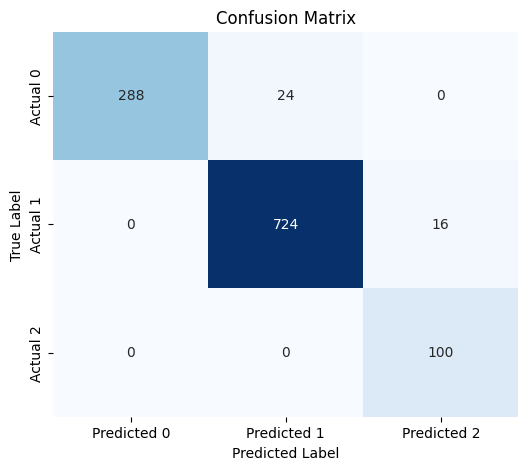

In [ ]:
confusion_l = metrics.confusion_matrix(y_test, y_prediction_discrete )
print(confusion)
#cm = confusion_matrix(y_test, y_prediction_discrete)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_l, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], # Updated for 3 classes
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])       # Updated for 3 classes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(metrics.accuracy_score(y_test, y_prediction_discrete))

0.9652777777777778


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_prediction_discrete))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       312
           1       0.97      0.98      0.97       740
           2       0.86      1.00      0.93       100

    accuracy                           0.97      1152
   macro avg       0.94      0.97      0.95      1152
weighted avg       0.97      0.97      0.97      1152



In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_validate, y_validate, cv=5)
print(scores.mean())

0.7379096034637008


In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Metrics for accuracy")



               Metrics for accuracy               




In [ ]:
#     CONFSUION MATRIX
TP_l = confusion_l[2,2]   # true positive
TN_l = confusion_l[0,0]+ confusion_l[1,1] + confusion_l[0,1] + confusion_l[1,0] # true negatives
FP_l = confusion_l[1,2] + confusion_l[0,2] # false positives
FN_l = confusion_l[2,0] + confusion_l[2,1] # false negatives

In [ ]:
# Let's see the sensitivity/Recall of our linear regression model
sensitivity = TP_l / float(TP_l+FN_l)

In [ ]:
# Let us calculate specificity
specificity = TN_l / float(TN_l+FP_l)
print(TN_l / float(TN_l+FP_l))

0.9847908745247148


In [ ]:
# Calculate false postive rate - Unneccessary Transactions decline
print(FP_l/ float(TN_l+FP_l))

0.015209125475285171


In [ ]:
# positive predictive value/Precision
print (TP_l / float(TP_l+FP_l))

0.8620689655172413


In [ ]:
# Negative predictive value - Non-Fraudulent Transactions Ratio
print (TN_l / float(TN_l+ FN_l))

1.0


In [ ]:
# False Negative predictive value - Undetected fraud
print (FN_l / float(TP_l+ FN_l))

0.0


=================================================
Supervised Learning
=================================================

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
y=df_main_normalized['Fraudulent']
print("Original Normalized Dataset Fruadulent column \n")
print(y)
#Putting the target variable in y and feature variable to X
X=df_main_normalized.drop(columns=['User_ID','Fraud_Score','Fraudulent'],axis=1)
print("Original Normalized Dataset wihtout Fruadulent column\n")
print(X)

#split the data
# First split: 80% for training, 20% for temp (test + validate)
X_train_xgb, X_temp_xgb, y_train_xgb, y_temp_xgb = train_test_split(X, y_actual, train_size=0.8, random_state=42)

# Second split: 50% of temp for test (0.1 of original), 50% for validate (0.1 of original)
X_test_xgb, X_validate_xgb, y_test_xgb, y_validate_xgb = train_test_split(X_temp_xgb, y_temp_xgb, test_size=0.5, random_state=42)

Original Normalized Dataset Fruadulent column 

0        1
1        1
2        2
3        1
4        1
        ..
11641    0
11642    1
11643    2
11644    1
11645    1
Name: Fraudulent, Length: 11521, dtype: category
Categories (3, int64): [0 < 1 < 2]
Original Normalized Dataset wihtout Fruadulent column

       Normalized_Amt  Normalized_History  Normalized_Frequency  \
0            0.310233                1.00              0.153846   
1            0.297400                0.50              0.461538   
2            0.473941                0.75              1.000000   
3            0.546397                0.50              0.000000   
4            0.903911                0.00              0.692308   
...               ...                 ...                   ...   
11641        0.163062                0.00              0.230769   
11642        0.846505                0.25              0.615385   
11643        0.381217                1.00              1.000000   
11644        0.579285 

In [ ]:
model_xgb = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss"
)
model_xgb.fit(X_train_xgb, y_train_xgb)
print(model_xgb.score(X_train_xgb, y_train_xgb))


1.0


In [ ]:
print(y_test_xgb[:10])

6260    1
6538    2
5679    1
5915    1
9498    1
9004    1
2083    1
1788    2
5824    1
5549    0
Name: Fraudulent, dtype: category
Categories (3, int64): [0 < 1 < 2]


In [ ]:
#Getting the predicted values on the test set
y_pred_xgb = model_xgb.predict(X_test_xgb)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
print(accuracy)

0.9548611111111112


[[292  20   0]
 [ 17 719   4]
 [  0  11  89]]


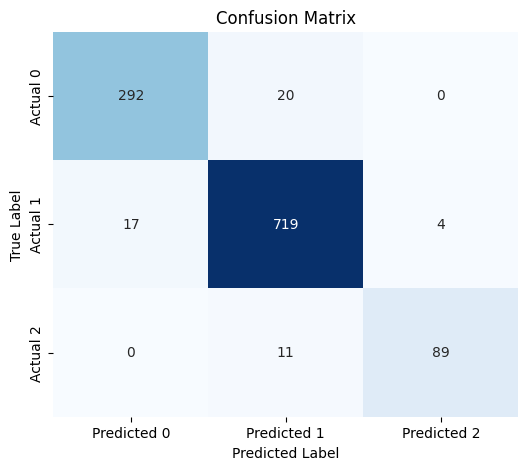

In [ ]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test_xgb, y_pred_xgb)
print(confusion)
 #Display Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], # Updated for 3 classes
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])       # Updated for 3 classes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print('\nXgboost Classification Report:')
print(classification_report(y_test_xgb, y_pred_xgb))


Xgboost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       312
           1       0.96      0.97      0.97       740
           2       0.96      0.89      0.92       100

    accuracy                           0.95      1152
   macro avg       0.95      0.93      0.94      1152
weighted avg       0.95      0.95      0.95      1152



In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_xgb, X_validate_xgb, y_validate_xgb, cv=5)
print(scores.mean())

0.9150084697910785


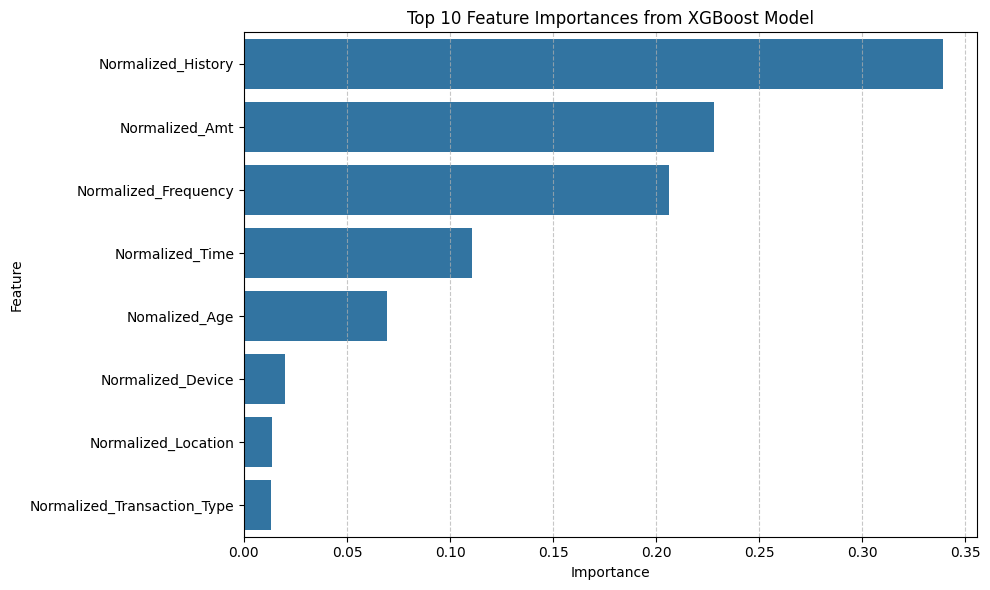

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the model
feature_importances = model_xgb.feature_importances_

# Create a DataFrame for better visualization
feature_df = pd.DataFrame({'Feature': X_train_xgb.columns, 'Importance': feature_importances})

# Sort the features by importance in descending order
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Display the top N features (e.g., top 10)
n_features = 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(n_features))
plt.title(f'Top {n_features} Feature Importances from XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
print(X_train_xgb.columns)

Index(['Normalized_Amt', 'Normalized_History', 'Normalized_Frequency',
       'Normalized_Time', 'Nomalized_Age', 'Normalized_Transaction_Type',
       'Normalized_Device', 'Normalized_Location'],
      dtype='object')


Accuracy: 0.9549
Precision: 0.9548
Recall: 0.9549
F1-Score: 0.9547
ROC AUC Score: 0.9950


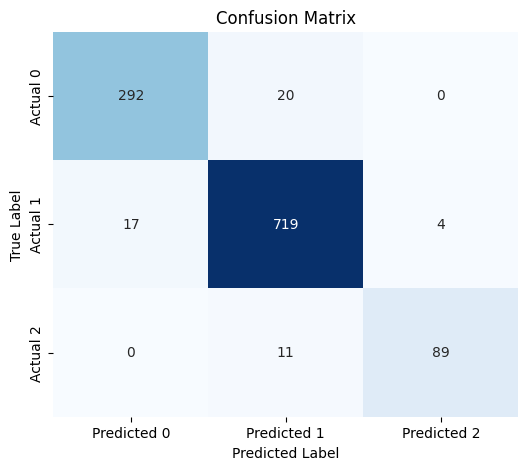

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
# Get predicted class labels
y_pred_xgb = model_xgb.predict(X_test_xgb)

# Get predicted probabilities for ROC AUC
y_pred_proba_actual = model_xgb.predict_proba(X_test_xgb)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
precision = precision_score(y_test_xgb, y_pred_xgb, average = 'weighted')
recall = recall_score(y_test_xgb, y_pred_xgb, average = 'weighted')
f1 = f1_score(y_test_xgb, y_pred_xgb, average = 'weighted')
# For multi-class ROC AUC, use 'ovr' (one-vs-rest) or 'ovo' (one-vs-one) strategy
roc_auc = roc_auc_score(y_test_xgb, y_pred_proba_actual, multi_class='ovr', average='weighted') # Use probabilities for ROC AUC

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Display Confusion Matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], # Updated for 3 classes
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])       # Updated for 3 classes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Metrics for accuracy")



               Metrics for accuracy               




In [ ]:
#     CONFSUION MATRIX
TP_x = cm_xgb[2,2]   # true positive
TN_x = cm_xgb[0,0]+ cm_xgb[1,1] + cm_xgb[0,1] + cm_xgb[1,0] # true negatives
FP_x = cm_xgb[1,2] + cm_xgb[0,2] # false positives
FN_x = cm_xgb[2,0] + cm_xgb[2,1] # false negatives

In [ ]:
# Let's see the sensitivity/Recall of our linear regression model
sensitivity = TP_x / float(TP_x+FN_x)

In [ ]:
# Let us calculate specificity
specificity = TN_x / float(TN_x+FP_x)
print(TN_x / float(TN_x+FP_x))

0.9961977186311787


In [ ]:
# Calculate false postive rate - Unneccessary Transactions decline
print(FP_x/ float(TN_x+FP_x))

0.0038022813688212928


In [ ]:
# positive predictive value/Precision
print (TP_x / float(TP_x+FP_x))

0.956989247311828


In [ ]:
# Negative predictive value - Non-Fraudulent Transactions Ratio
print (TN_x / float(TN_x+ FN_x))

0.9896128423040604


In [ ]:
# False Negative predictive value - Undetected fraud
print (FN_x / float(TP_x+ FN_x))

0.11


==================================================

                  Anomaly Detection             

==================================================

In [ ]:
from sklearn.neural_network import BernoulliRBM
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
y=df_main_normalized['Fraudulent']
print("Original Normalized Dataset Fruadulent column \n")
print(y)
#Putting the target variable in y and feature variable to X
X=df_main_normalized.drop(columns=['User_ID','Fraud_Score','Fraudulent'],axis=1)
print("Original Normalized Dataset wihtout Fruadulent column\n")
print(X)

#split the data
# First split: 80% for training, 20% for temp (test + validate)
X_train_rbm, X_temp_rbm, y_train_rbm, y_temp_rbm = train_test_split(X, y_actual, train_size=0.8, random_state=42)

# Second split: 50% of temp for test (0.1 of original), 50% for validate (0.1 of original)
X_test_rbm, X_validate_rbm, y_test_rbm, y_validate_rbm = train_test_split(X_temp_rbm, y_temp_rbm, test_size=0.5, random_state=42)

Original Normalized Dataset Fruadulent column 

0        1
1        1
2        2
3        1
4        1
        ..
11641    0
11642    1
11643    2
11644    1
11645    1
Name: Fraudulent, Length: 11521, dtype: category
Categories (3, int64): [0 < 1 < 2]
Original Normalized Dataset wihtout Fruadulent column

       Normalized_Amt  Normalized_History  Normalized_Frequency  \
0            0.310233                1.00              0.153846   
1            0.297400                0.50              0.461538   
2            0.473941                0.75              1.000000   
3            0.546397                0.50              0.000000   
4            0.903911                0.00              0.692308   
...               ...                 ...                   ...   
11641        0.163062                0.00              0.230769   
11642        0.846505                0.25              0.615385   
11643        0.381217                1.00              1.000000   
11644        0.579285 

In [ ]:

# Train RBM
rbm = BernoulliRBM(n_components=64, learning_rate=0.01, n_iter=20)
rbm.fit(X_train_rbm)

# Reconstruct data
hidden = rbm.transform(X_test_rbm)
reconstructed = np.dot(hidden, rbm.components_)

# Reconstruction error
error = np.mean((X_test_rbm - reconstructed) ** 2, axis=1)

# Define thresholds for 3 classes (0, 1, 2)
min_error = error.min()
max_error = error.max()
percentile_25_error = np.percentile(error, 25)
percentile_90_error = np.percentile(error, 90)

# Assign anomalies to 3 classes
anomalies = pd.cut(error,
                   bins=[min_error, percentile_25_error, percentile_90_error, max_error],
                   labels=[0, 1, 2],
                   include_lowest=True)


RBM Anomaly Detection Confusion Matrix:
[[227  85   0]
 [ 61 630  49]
 [  0  33  67]]


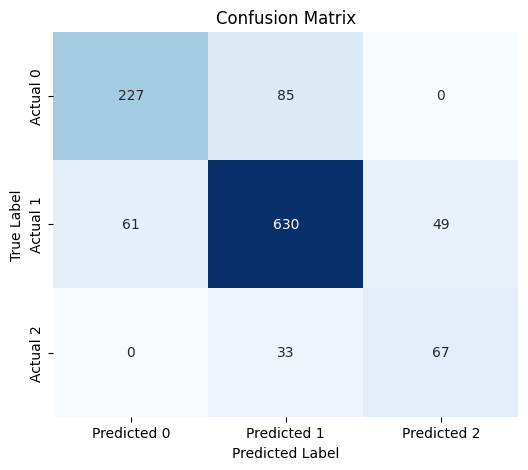

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix for RBM anomaly detection
rbm_confusion = confusion_matrix(y_test_rbm, anomalies)
print('RBM Anomaly Detection Confusion Matrix:')
print(rbm_confusion)
cm = confusion_matrix(y_test_rbm, anomalies)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], # Updated for 3 classes
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])       # Updated for 3 classes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Classification Report for RBM anomaly detection
print('\nRBM Anomaly Detection Classification Report:')
print(classification_report(y_test_rbm, anomalies))



RBM Anomaly Detection Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       312
           1       0.84      0.85      0.85       740
           2       0.58      0.67      0.62       100

    accuracy                           0.80      1152
   macro avg       0.74      0.75      0.74      1152
weighted avg       0.80      0.80      0.80      1152



In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_validate_rbm, y_validate_rbm, cv=5)
print(scores.mean())

0.737777740623357


In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Metrics for accuracy")



               Metrics for accuracy               




In [ ]:
#     CONFSUION MATRIX
TP_r = rbm_confusion[2,2]   # true positive
TN_r = rbm_confusion[0,0]+ rbm_confusion[1,1] + rbm_confusion[0,1] + rbm_confusion[1,0] # true negatives
FP_r = rbm_confusion[1,2] + rbm_confusion[0,2] # false positives
FN_r = rbm_confusion[2,0] + rbm_confusion[2,1] # false negatives

In [ ]:
# Let's see the sensitivity/Recall of our linear regression model
sensitivity = TP_r / float(TP_r+FN_r)

In [ ]:
# Let us calculate specificity
specificity = TN_r / float(TN_r+FP_r)
print(TN_r / float(TN_r+FP_r))

0.9534220532319392


In [ ]:
# Calculate false postive rate - Unneccessary Transactions decline
print(FP_r/ float(TN_r+FP_r))

0.04657794676806084


In [ ]:
# positive predictive value/Precision
print (TP_r / float(TP_r+FP_r))

0.5775862068965517


In [ ]:
# Negative predictive value - Non-Fraudulent Transactions Ratio
print (TN_r / float(TN_r+ FN_r))

0.9681467181467182


In [ ]:
# False Negative predictive value - Undetected fraud
print (FN_r / float(TP_r+ FN_r))

0.33


In [ ]:
def heading(title):
    print("\n" + "="*50)
    print(f"\n{title.center(50)}\n")
    print("="*50 + "\n" )
heading( "Model Transaparency")



               Model Transaparency                




In [ ]:
false_pos_idx = (y_pred_xgb == 1) & (y_test_xgb == 0)
X_fp = X_test_xgb[false_pos_idx]

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_fp)

In [ ]:
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_fp.iloc[0])

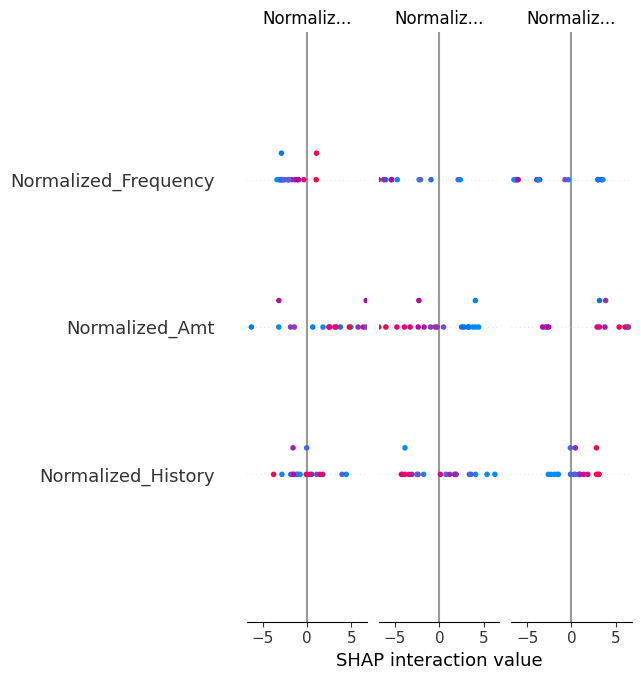

In [ ]:
shap.summary_plot(shap_values, X_fp)

In [ ]:
shap.force_plot(explainer.expected_value[2], shap_values[1, :, 1], X_fp.iloc[1])

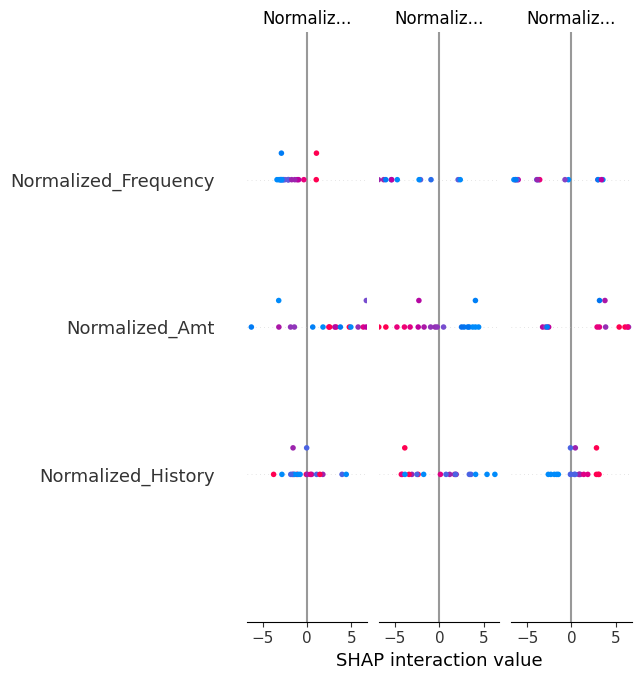

In [ ]:
shap.summary_plot(shap_values, X_fp)

The `shap_values` array has a shape of `(n_samples, n_features, n_classes)` (in this case, `(20, 8, 3)`). To visualize the SHAP summary for each class in a multi-class model, we need to pass the SHAP values for each class separately to `shap.summary_plot`.

Summary plot for Class 0:


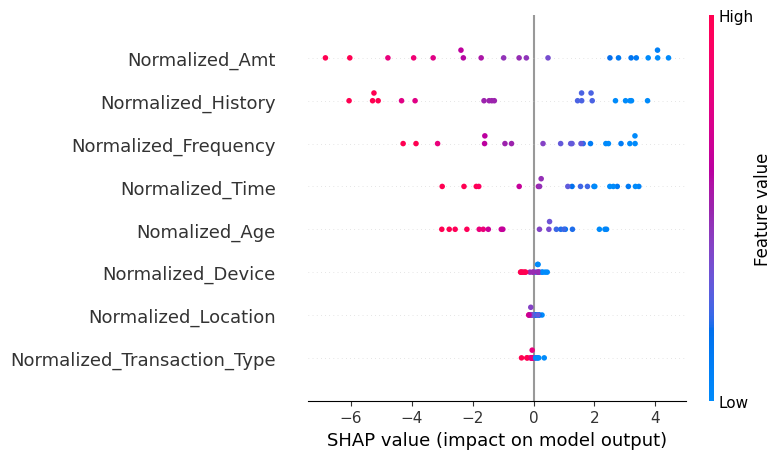

In [ ]:
# Plotting summary plot for Class 0
print('Summary plot for Class 0:')
shap.summary_plot(shap_values[:, :, 0], X_fp)

Summary plot for Class 1:


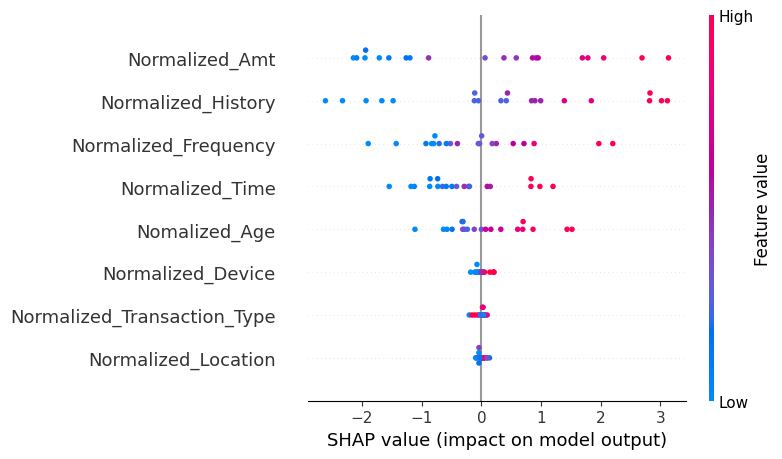

In [ ]:
# Plotting summary plot for Class 1
print('Summary plot for Class 1:')
shap.summary_plot(shap_values[:, :, 1], X_fp)

Summary plot for Class 2:


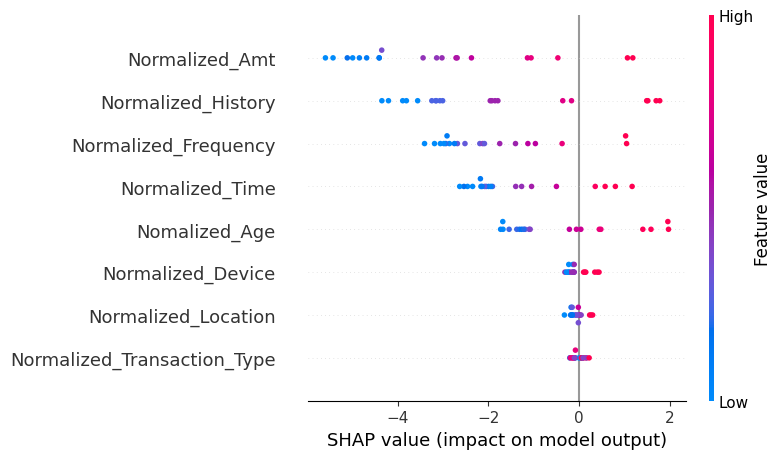

In [ ]:
# Plotting summary plot for Class 2
print('Summary plot for Class 2:')
shap.summary_plot(shap_values[:, :, 2], X_fp)

In [ ]:
shap.force_plot(explainer.expected_value[0], shap_values[0, :, 0], X_fp.iloc[0])

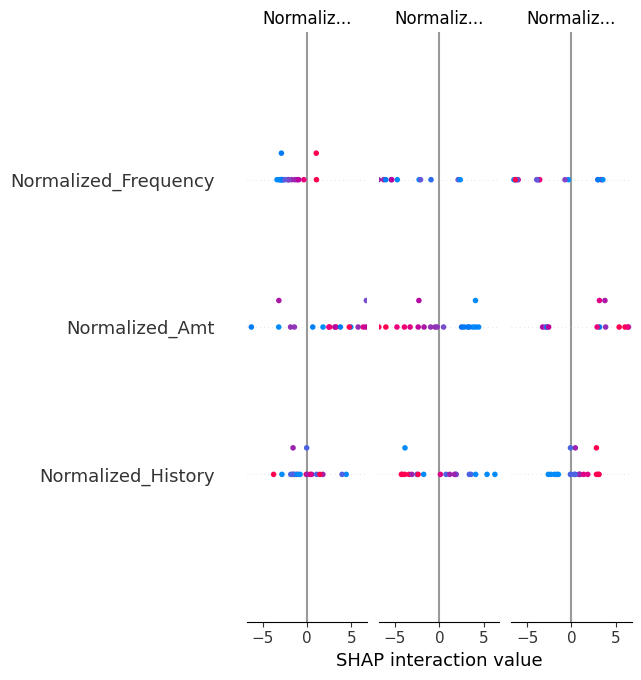

In [ ]:
shap.summary_plot(shap_values, X_fp)

Aggregated SHAP Summary Plot for all Classes:


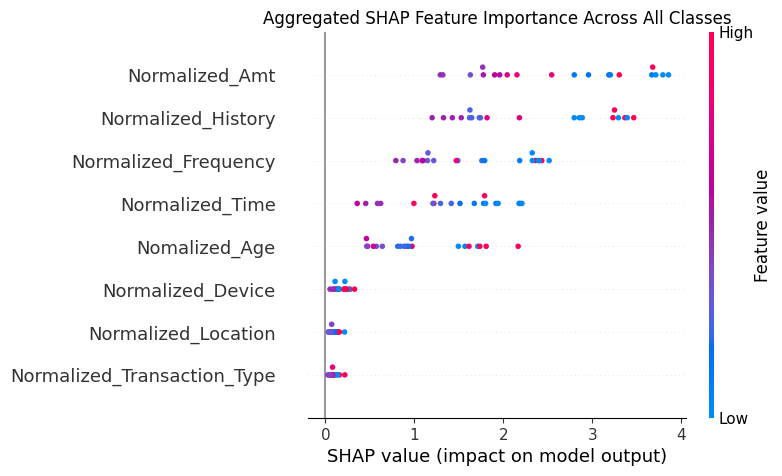

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean absolute SHAP values across classes for each feature
shap_values_aggregated = np.abs(shap_values).mean(axis=2)

print('Aggregated SHAP Summary Plot for all Classes:')
shap.summary_plot(shap_values_aggregated, X_fp, show=False)
plt.title('Aggregated SHAP Feature Importance Across All Classes')
plt.show()

In [ ]:
print(shap_values.shape)

(20, 8, 3)


In [ ]:
display(feature_df)

,Feature,Importance
1,Normalized_History,0.338926
0,Normalized_Amt,0.228290
2,Normalized_Frequency,0.206168
3,Normalized_Time,0.110741
4,Nomalized_Age,0.069300
6,Normalized_Device,0.019721
7,Normalized_Location,0.013718
5,Normalized_Transaction_Type,0.013137
